## Week 3: Earnings Call
## April 7, 2024
### Annica Gaebel

In [2]:
%pip install PyPDF2 nltk textblob

Note: you may need to restart the kernel to use updated packages.


In [3]:
import nltk
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [4]:
import os
import PyPDF2
from collections import Counter
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize
from textblob import TextBlob

# Path to your folder
folder_path = r"C:\Users\agaebel\OneDrive - Elon University\Documents\MSBA Program\MSBA 6680 Financial Industry Analytics\Week 3"

# Stopwords set
stop_words = set(stopwords.words("english"))

# Store results
all_results = {}

def extract_text_from_pdf(file_path):
    text = ""
    with open(file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text
    return text

# Loop through PDFs in folder
for filename in os.listdir(folder_path):
    if filename.endswith(".pdf"):
        file_path = os.path.join(folder_path, filename)
        print(f"Processing: {filename}")

        # Extract and clean text
        raw_text = extract_text_from_pdf(file_path)
        tokens = word_tokenize(raw_text.lower())
        words = [word for word in tokens if word.isalpha() and word not in stop_words]
        
        # Text stats
        word_count = len(words)
        top_words = Counter(words).most_common(10)
        sentiment = TextBlob(raw_text).sentiment

        # Store results
        all_results[filename] = {
            "word_count": word_count,
            "top_words": top_words,
            "sentiment_polarity": sentiment.polarity,
            "sentiment_subjectivity": sentiment.subjectivity
        }

# Print results
for file, stats in all_results.items():
    print(f"\n📄 {file}")
    print(f" - Word Count: {stats['word_count']}")
    print(f" - Top Words: {stats['top_words']}")
    print(f" - Sentiment Polarity: {stats['sentiment_polarity']:.3f}")
    print(f" - Sentiment Subjectivity: {stats['sentiment_subjectivity']:.3f}")


Processing: ABNB - Q1 2024 Earnings Call 8May2024 430 PM ET CORRECTED TRANSCRIPT - 08-May-24.pdf
Processing: ABNB - Q2 2024 Earnings Call 6August2024 430 PM ET CORRECTED TRANSCRIPT - 06-Aug-24.pdf
Processing: ABNB - Q3 2024 Earnings Call 7November2024 430 PM ET CORRECTED TRANSCRIPT - 07-Nov-24.pdf
Processing: ABNB - Q4 2023 Earnings Call 13February2024 430 PM ET CORRECTED TRANSCRIPT - 13-Feb-24.pdf
Processing: ABNB - Q4 2024 Earnings Call 13February2025 430 PM ET CORRECTED TRANSCRIPT - 13-Feb-25.pdf

📄 ABNB - Q1 2024 Earnings Call 8May2024 430 PM ET CORRECTED TRANSCRIPT - 08-May-24.pdf
 - Word Count: 5969
 - Top Words: [('airbnb', 109), ('year', 69), ('think', 69), ('would', 60), ('really', 58), ('llc', 53), ('people', 45), ('analyst', 44), ('one', 43), ('call', 41)]
 - Sentiment Polarity: 0.166
 - Sentiment Subjectivity: 0.408

📄 ABNB - Q2 2024 Earnings Call 6August2024 430 PM ET CORRECTED TRANSCRIPT - 06-Aug-24.pdf
 - Word Count: 5778
 - Top Words: [('airbnb', 112), ('think', 69), ('

In [5]:
import os
import PyPDF2
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from textblob import TextBlob

# Download necessary NLTK data (if not already downloaded)
nltk.download("punkt")
nltk.download("stopwords")

# Define the folder containing your PDF files
folder_path = r"C:\Users\agaebel\OneDrive - Elon University\Documents\MSBA Program\MSBA 6680 Financial Industry Analytics\Week 3"

# Function to extract text from a PDF file
def extract_text_from_pdf(pdf_file_path):
    """Extracts text from a PDF file."""
    text = ""
    with open(pdf_file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:  # Check if text extraction was successful
                text += page_text
    return text

# Set up the English stopwords list from NLTK
stop_words = set(stopwords.words("english"))

# Dictionary to hold analysis results for each PDF
analysis_results = {}

# Loop through every file in the specified folder
for filename in os.listdir(folder_path):
    # Process only PDF files (case-insensitive check)
    if filename.lower().endswith(".pdf"):
        file_path = os.path.join(folder_path, filename)
        print(f"Processing file: {filename}")
        
        # Extract text from the PDF
        raw_text = extract_text_from_pdf(file_path)
        
        # Tokenize text, convert to lower case, and filter to keep only alphabetic words 
        tokens = word_tokenize(raw_text.lower())
        words = [word for word in tokens if word.isalpha() and word not in stop_words]
        
        # Calculate basic text statistics
        word_count = len(words)
        top_words = Counter(words).most_common(10)
        
        # Compute sentiment using TextBlob (returns polarity and subjectivity)
        sentiment_analysis = TextBlob(raw_text).sentiment
        
        # Store all results in the dictionary
        analysis_results[filename] = {
            "word_count": word_count,
            "top_words": top_words,
            "sentiment": {
                "polarity": sentiment_analysis.polarity,
                "subjectivity": sentiment_analysis.subjectivity
            }
        }

print("\n--- Textual Analysis Completed ---\n")
# Display results for each PDF file
for file, stats in analysis_results.items():
    print(f"File: {file}")
    print(f"Word Count: {stats['word_count']}")
    print("Top 10 Words:")
    for word, count in stats["top_words"]:
        print(f"  {word}: {count}")
    print("Sentiment:")
    print(f"  Polarity: {stats['sentiment']['polarity']:.3f} (ranges from -1 [negative] to 1 [positive])")
    print(f"  Subjectivity: {stats['sentiment']['subjectivity']:.3f} (ranges from 0 [objective] to 1 [subjective])")
    print("-" * 50)


Processing file: ABNB - Q1 2024 Earnings Call 8May2024 430 PM ET CORRECTED TRANSCRIPT - 08-May-24.pdf


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Processing file: ABNB - Q2 2024 Earnings Call 6August2024 430 PM ET CORRECTED TRANSCRIPT - 06-Aug-24.pdf
Processing file: ABNB - Q3 2024 Earnings Call 7November2024 430 PM ET CORRECTED TRANSCRIPT - 07-Nov-24.pdf
Processing file: ABNB - Q4 2023 Earnings Call 13February2024 430 PM ET CORRECTED TRANSCRIPT - 13-Feb-24.pdf
Processing file: ABNB - Q4 2024 Earnings Call 13February2025 430 PM ET CORRECTED TRANSCRIPT - 13-Feb-25.pdf

--- Textual Analysis Completed ---

File: ABNB - Q1 2024 Earnings Call 8May2024 430 PM ET CORRECTED TRANSCRIPT - 08-May-24.pdf
Word Count: 5969
Top 10 Words:
  airbnb: 109
  year: 69
  think: 69
  would: 60
  really: 58
  llc: 53
  people: 45
  analyst: 44
  one: 43
  call: 41
Sentiment:
  Polarity: 0.166 (ranges from -1 [negative] to 1 [positive])
  Subjectivity: 0.408 (ranges from 0 [objective] to 1 [subjective])
--------------------------------------------------
File: ABNB - Q2 2024 Earnings Call 6August2024 430 PM ET CORRECTED TRANSCRIPT - 06-Aug-24.pdf
Word Co

In [6]:
import os
import PyPDF2
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from textblob import TextBlob

# Download necessary NLTK data (if not already downloaded)
nltk.download("punkt")
nltk.download("stopwords")

# Define the folder containing your PDF files
folder_path = r"C:\Users\agaebel\OneDrive - Elon University\Documents\MSBA Program\MSBA 6680 Financial Industry Analytics\Week 3"

# Function to extract text from a PDF file
def extract_text_from_pdf(pdf_file_path):
    """Extracts text from a PDF file."""
    text = ""
    with open(pdf_file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:  # Check if text extraction was successful
                text += page_text
    return text

# Set up the English stopwords list from NLTK
stop_words = set(stopwords.words("english"))

# Dictionary to hold analysis results for each PDF
analysis_results = {}

# Loop through every file in the specified folder
for filename in os.listdir(folder_path):
    # Process only PDF files (case-insensitive check)
    if filename.lower().endswith(".pdf"):
        file_path = os.path.join(folder_path, filename)
        print(f"Processing file: {filename}")
        
        # Extract text from the PDF
        raw_text = extract_text_from_pdf(file_path)
        
        # Tokenize text, convert to lower case, and filter to keep only alphabetic words 
        tokens = word_tokenize(raw_text.lower())
        words = [word for word in tokens if word.isalpha() and word not in stop_words]
        
        # Calculate basic text statistics
        word_count = len(words)
        top_words = Counter(words).most_common(10)
        
        # Compute sentiment using TextBlob (returns polarity and subjectivity)
        sentiment_analysis = TextBlob(raw_text).sentiment
        
        # Determine sentiment classification based on polarity threshold
        if sentiment_analysis.polarity > 0.1:
            sentiment_label = "Positive"
        elif sentiment_analysis.polarity < -0.1:
            sentiment_label = "Negative"
        else:
            sentiment_label = "Neutral"
        
        # Store all results in the dictionary
        analysis_results[filename] = {
            "word_count": word_count,
            "top_words": top_words,
            "sentiment": {
                "polarity": sentiment_analysis.polarity,
                "subjectivity": sentiment_analysis.subjectivity,
                "label": sentiment_label
            }
        }

print("\n--- Textual Analysis Completed ---\n")
# Display results for each PDF file
for file, stats in analysis_results.items():
    print(f"File: {file}")
    print(f"Word Count: {stats['word_count']}")
    print("Top 10 Words:")
    for word, count in stats["top_words"]:
        print(f"  {word}: {count}")
    print("Sentiment:")
    print(f"  Polarity: {stats['sentiment']['polarity']:.3f} (ranges from -1 [negative] to 1 [positive])")
    print(f"  Subjectivity: {stats['sentiment']['subjectivity']:.3f} (ranges from 0 [objective] to 1 [subjective])")
    print(f"  Overall Sentiment: {stats['sentiment']['label']}")
    print("-" * 50)


Processing file: ABNB - Q1 2024 Earnings Call 8May2024 430 PM ET CORRECTED TRANSCRIPT - 08-May-24.pdf


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Processing file: ABNB - Q2 2024 Earnings Call 6August2024 430 PM ET CORRECTED TRANSCRIPT - 06-Aug-24.pdf
Processing file: ABNB - Q3 2024 Earnings Call 7November2024 430 PM ET CORRECTED TRANSCRIPT - 07-Nov-24.pdf
Processing file: ABNB - Q4 2023 Earnings Call 13February2024 430 PM ET CORRECTED TRANSCRIPT - 13-Feb-24.pdf
Processing file: ABNB - Q4 2024 Earnings Call 13February2025 430 PM ET CORRECTED TRANSCRIPT - 13-Feb-25.pdf

--- Textual Analysis Completed ---

File: ABNB - Q1 2024 Earnings Call 8May2024 430 PM ET CORRECTED TRANSCRIPT - 08-May-24.pdf
Word Count: 5969
Top 10 Words:
  airbnb: 109
  year: 69
  think: 69
  would: 60
  really: 58
  llc: 53
  people: 45
  analyst: 44
  one: 43
  call: 41
Sentiment:
  Polarity: 0.166 (ranges from -1 [negative] to 1 [positive])
  Subjectivity: 0.408 (ranges from 0 [objective] to 1 [subjective])
  Overall Sentiment: Positive
--------------------------------------------------
File: ABNB - Q2 2024 Earnings Call 6August2024 430 PM ET CORRECTED TRAN

## Analyze Earnings Calls by Sections

In [7]:
import os
import re
import PyPDF2
from collections import Counter
import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from textblob import TextBlob

# Download necessary NLTK data (if not already downloaded)
nltk.download("punkt")
nltk.download("stopwords")

# Define the folder containing your conference call PDFs
# Replace "folder" with your actual folder path if needed.
folder_path = r"C:\Users\agaebel\OneDrive - Elon University\Documents\MSBA Program\MSBA 6680 Financial Industry Analytics\Week 3"

# Set up English stopwords from NLTK
stop_words = set(stopwords.words("english"))

def extract_text_from_pdf(pdf_file_path):
    """Extracts all text from a PDF file."""
    text = ""
    with open(pdf_file_path, "rb") as file:
        reader = PyPDF2.PdfReader(file)
        for page in reader.pages:
            page_text = page.extract_text()
            if page_text:
                text += page_text + "\n"
    return text

def split_into_sections(text):
    """
    Splits text into sections based on common transcript section headings.
    This example uses a simple regex that attempts to split on newline characters
    when a new section header is detected. You can adjust the regex pattern based on
    the formatting of your transcripts. Here we assume section headers might be written in all uppercase,
    or might be common phrases like "Management Discussion", "Q&A", etc.
    """
    # The pattern checks for a newline followed by either several uppercase letters (with possible spaces)
    # or specific section titles.
    pattern = r'\n(?=(?:[A-Z\s]{3,}|Management Discussion|Q&A|Question and Answer))'
    sections = re.split(pattern, text)
    return sections

def analyze_text(text):
    """
    Performs basic textual analysis on the text:
      - Word count (after tokenization and stopword removal)
      - Top 10 most common words
      - Sentiment analysis (polarity and subjectivity)
    """
    tokens = word_tokenize(text.lower())
    words = [word for word in tokens if word.isalpha() and word not in stop_words]
    
    word_count = len(words)
    top_words = Counter(words).most_common(10)
    sentiment = TextBlob(text).sentiment  # Returns a tuple (polarity, subjectivity)
    
    return {
        'word_count': word_count,
        'top_words': top_words,
        'sentiment': {'polarity': sentiment.polarity, 'subjectivity': sentiment.subjectivity}
    }

# Dictionary to hold analysis results for each document
results = {}

# Loop through each PDF file in the folder
for filename in os.listdir(folder_path):
    if filename.lower().endswith(".pdf"):
        file_path = os.path.join(folder_path, filename)
        print(f"Processing document: {filename}")
        
        # Extract full text from PDF
        raw_text = extract_text_from_pdf(file_path)
        
        # Split the full text into sections
        sections = split_into_sections(raw_text)
        
        # Analyze overall document text
        overall_analysis = analyze_text(raw_text)
        
        # Analyze each section separately
        section_analysis = {}
        for idx, section in enumerate(sections):
            # Use the first line as a section title (if it exists)
            lines = section.strip().split("\n")
            if lines and len(lines[0].strip()) > 0:
                title = lines[0].strip()
            else:
                title = f"Section {idx+1}"
            analysis = analyze_text(section)
            section_analysis[title] = analysis
        
        # Save results for the current document
        results[filename] = {
            'overall': overall_analysis,
            'sections': section_analysis
        }

# Print out the analysis results for each document
for doc, doc_data in results.items():
    print(f"\n--- Document: {doc} ---")
    overall = doc_data['overall']
    print("Overall Analysis:")
    print(f"  Word Count: {overall['word_count']}")
    print(f"  Top Words: {overall['top_words']}")
    print(f"  Sentiment: Polarity = {overall['sentiment']['polarity']:.3f}, Subjectivity = {overall['sentiment']['subjectivity']:.3f}")
    print("Section Analysis:")
    for section_title, analysis in doc_data['sections'].items():
        print(f"  Section: {section_title}")
        print(f"    Word Count: {analysis['word_count']}")
        print(f"    Top Words: {analysis['top_words']}")
        print(f"    Sentiment: Polarity = {analysis['sentiment']['polarity']:.3f}, Subjectivity = {analysis['sentiment']['subjectivity']:.3f}")


Processing document: ABNB - Q1 2024 Earnings Call 8May2024 430 PM ET CORRECTED TRANSCRIPT - 08-May-24.pdf


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


Processing document: ABNB - Q2 2024 Earnings Call 6August2024 430 PM ET CORRECTED TRANSCRIPT - 06-Aug-24.pdf
Processing document: ABNB - Q3 2024 Earnings Call 7November2024 430 PM ET CORRECTED TRANSCRIPT - 07-Nov-24.pdf
Processing document: ABNB - Q4 2023 Earnings Call 13February2024 430 PM ET CORRECTED TRANSCRIPT - 13-Feb-24.pdf
Processing document: ABNB - Q4 2024 Earnings Call 13February2025 430 PM ET CORRECTED TRANSCRIPT - 13-Feb-25.pdf

--- Document: ABNB - Q1 2024 Earnings Call 8May2024 430 PM ET CORRECTED TRANSCRIPT - 08-May-24.pdf ---
Overall Analysis:
  Word Count: 5969
  Top Words: [('airbnb', 109), ('year', 69), ('think', 69), ('would', 60), ('really', 58), ('llc', 53), ('people', 45), ('analyst', 44), ('one', 43), ('call', 41)]
  Sentiment: Polarity = 0.166, Subjectivity = 0.408
Section Analysis:
  Section: Contents
    Word Count: 9
    Top Words: [('corrected', 2), ('transcript', 2), ('contents', 1), ('earnings', 1), ('call', 1), ('pm', 1), ('et', 1)]
    Sentiment: Polari

# FinBERT

In [8]:
pip install PyPDF2 transformers torch matplotlib nltk pandas

Note: you may need to restart the kernel to use updated packages.


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\agaebel\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


Device set to use cpu


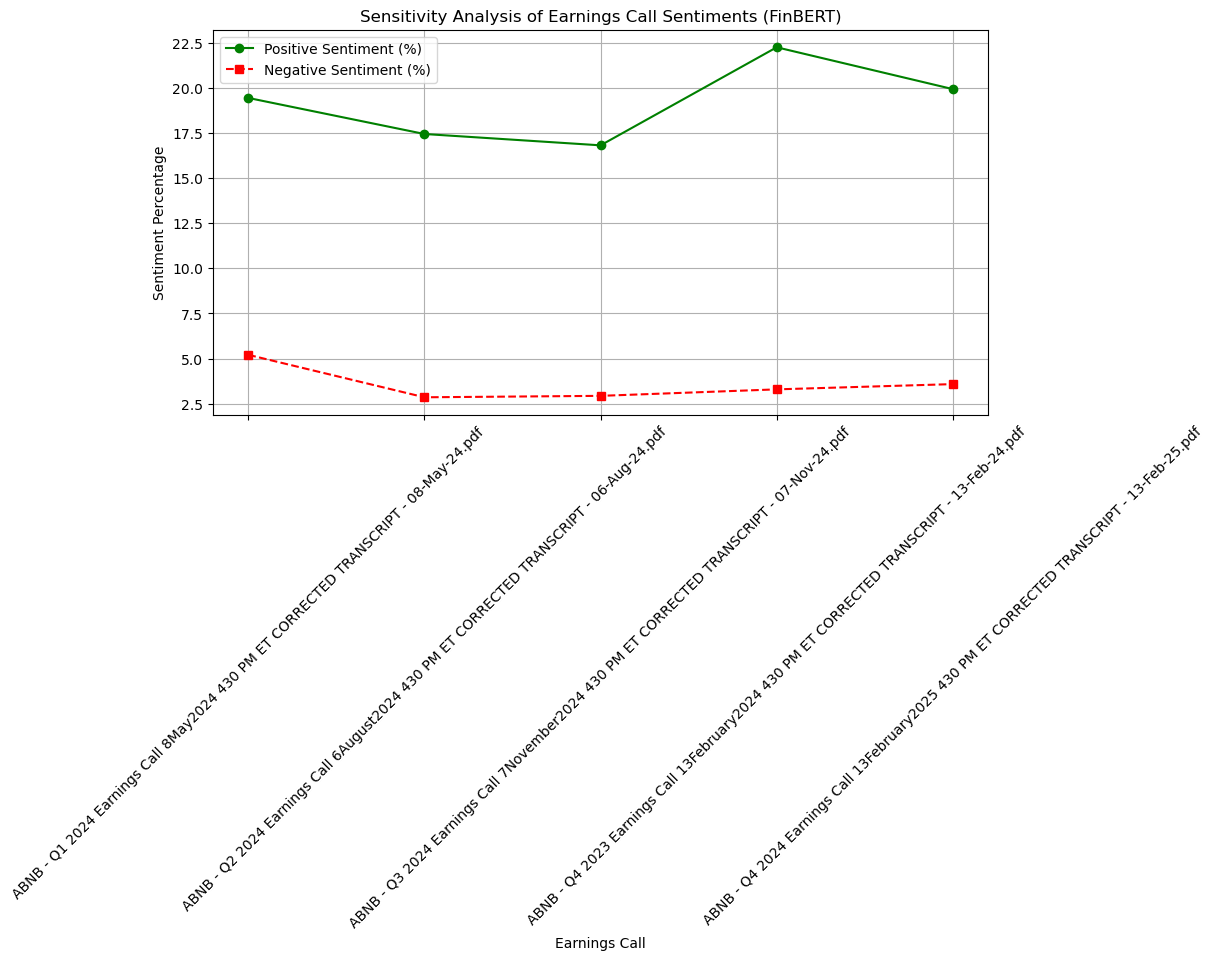

                                       Earnings Call  Positive  Neutral  \
0  ABNB - Q1 2024 Earnings Call 8May2024 430 PM E...       127      492   
1  ABNB - Q2 2024 Earnings Call 6August2024 430 P...       104      475   
2  ABNB - Q3 2024 Earnings Call 7November2024 430...       109      520   
3  ABNB - Q4 2023 Earnings Call 13February2024 43...       142      475   
4  ABNB - Q4 2024 Earnings Call 13February2025 43...       128      491   

   Negative  Total Sentences  Positive %  Negative %  
0        34              653   19.448698    5.206738  
1        17              596   17.449664    2.852349  
2        19              648   16.820988    2.932099  
3        21              638   22.257053    3.291536  
4        23              642   19.937695    3.582555  


In [9]:
import os
import PyPDF2
import nltk
from nltk.tokenize import sent_tokenize
import pandas as pd
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, pipeline

# Download NLTK tokenizer (if not already installed)
nltk.download("punkt")

# Load FinBERT model and tokenizer
tokenizer = AutoTokenizer.from_pretrained("ProsusAI/finbert")
sentiment_pipeline = pipeline("text-classification", model="ProsusAI/finbert")

# Folder containing earnings call PDFs
folder_path = r"C:\Users\agaebel\OneDrive - Elon University\Documents\MSBA Program\MSBA 6680 Financial Industry Analytics\Week 3"

# Function to extract text from a PDF file
def extract_text_from_pdf(pdf_path):
    text = ""
    with open(pdf_path, "rb") as pdf_file:
        reader = PyPDF2.PdfReader(pdf_file)
        for page in reader.pages:
            text += page.extract_text() + "\n"
    return text

# Function to process sentences safely (truncate if >512 tokens)
def analyze_text_with_truncation(text):
    tokenized_text = tokenizer.encode(text, truncation=True, max_length=512, return_tensors="pt")
    sentiment = sentiment_pipeline(text[:512])[0]  # Only send 512 chars to avoid token mismatch
    return sentiment

# Process each PDF in the folder
sentiment_results = []
for filename in os.listdir(folder_path):
    if filename.endswith(".pdf"):
        file_path = os.path.join(folder_path, filename)
        
        # Extract text from PDF
        transcript_text = extract_text_from_pdf(file_path)
        sentences = sent_tokenize(transcript_text)

        # Run sentiment analysis with truncation
        sentiments = [analyze_text_with_truncation(sentence) for sentence in sentences]

        # Count sentiment distribution
        sentiment_counts = {
            "positive": sum(1 for s in sentiments if s["label"] == "positive"),
            "neutral": sum(1 for s in sentiments if s["label"] == "neutral"),
            "negative": sum(1 for s in sentiments if s["label"] == "negative")
        }
        
        # Store results
        sentiment_results.append({
            "Earnings Call": filename,
            "Positive": sentiment_counts["positive"],
            "Neutral": sentiment_counts["neutral"],
            "Negative": sentiment_counts["negative"],
            "Total Sentences": len(sentiments),
            "Positive %": sentiment_counts["positive"] / len(sentiments) * 100,
            "Negative %": sentiment_counts["negative"] / len(sentiments) * 100
        })

# Convert results to DataFrame
df_results = pd.DataFrame(sentiment_results)

# 🎨 Plot sensitivity analysis (Positive vs. Negative %)
plt.figure(figsize=(10, 5))
plt.plot(df_results["Earnings Call"], df_results["Positive %"], marker="o", linestyle="-", label="Positive Sentiment (%)", color="green")
plt.plot(df_results["Earnings Call"], df_results["Negative %"], marker="s", linestyle="--", label="Negative Sentiment (%)", color="red")
plt.xlabel("Earnings Call")
plt.ylabel("Sentiment Percentage")
plt.title("Sensitivity Analysis of Earnings Call Sentiments (FinBERT)")
plt.xticks(rotation=45)
plt.legend()
plt.grid()
plt.show()

# 📊 Print summarized sensitivity results
print(df_results)


In [10]:
import pandas as pd
import numpy as np
import yfinance as yf
import re

# -- 1. Retrieve just the 'Close' column from yfinance as a single-level DataFrame
df_stock = yf.download("ABNB", start="2024-01-01", end="2025-03-01")[['Close']].dropna()

# Calculate daily returns and annualized volatility on this single-level DataFrame
df_stock['Returns'] = df_stock['Close'].pct_change()
df_stock['Volatility'] = df_stock['Returns'].rolling(window=252).std() * np.sqrt(252)

# -- 2. Recompute stock movement for your earnings call dates --
input_dates = ['2024-02-13', '2024-05-08', '2024-08-06', '2024-11-07', '2025-02-13']
stock_movement = []
for date_str in input_dates:
    date = pd.to_datetime(date_str)
    try:
        date_idx = df_stock.index.get_loc(date)
        
        # Force close_price to be a scalar
        close_price = df_stock.loc[date, 'Close']
        if isinstance(close_price, pd.Series):
            close_price = close_price.iloc[0]
        
        row = {'Date': date.strftime('%Y-%m-%d'), 'Close Price': close_price}
        
        # Calculate returns for offsets: 1D=1 row, 3D=3 rows, 5D=5 rows, 1W=7 rows.
        for label, offset in [('1D', 1), ('3D', 3), ('5D', 5), ('1W', 7)]:
            if (date_idx + offset) < len(df_stock):
                future_close = df_stock['Close'].iloc[date_idx + offset]
                if isinstance(future_close, pd.Series):
                    future_close = future_close.iloc[0]
                row[f'{label} Return'] = (future_close - close_price) / close_price
            else:
                row[f'{label} Return'] = np.nan
        
        stock_movement.append(row)
    
    except Exception as e:
        print(f"Error processing date {date_str}: {e}")

movement_df = pd.DataFrame(stock_movement)

# -- 3. Map each date to a Quarter label for merging --
quarter_map = {
    '2024-02-13': 'Q4 2023',
    '2024-05-08': 'Q1 2024',
    '2024-08-06': 'Q2 2024',
    '2024-11-07': 'Q3 2024',
    '2025-02-13': 'Q4 2024'
}
movement_df['Quarter'] = movement_df['Date'].map(quarter_map)

# -- 4. Use your existing sentiment DataFrame (df_results) and add a 'Quarter' column --
def extract_quarter_from_filename(filename):
    match = re.search(r'(Q[1-4]\s*\d{4})', filename.upper())
    return match.group(1).strip() if match else None

df_results['Quarter'] = df_results['Earnings Call'].apply(extract_quarter_from_filename)

# -- 5. Merge the sentiment and stock movement DataFrames on 'Quarter' --
merged_df = pd.merge(df_results, movement_df, on='Quarter', how='inner').reset_index(drop=True)

# Compute the Positive/Negative ratio.
merged_df['Pos/Neg Ratio'] = merged_df.apply(lambda row: row['Positive'] / row['Negative']
                                               if row['Negative'] > 0 else np.nan, axis=1)

# Select and order desired columns.
final_df = merged_df[['Quarter', 'Positive', 'Negative', 'Pos/Neg Ratio',
                        '1D Return', '3D Return', '5D Return', '1W Return']]

# -- 6. Sort the final DataFrame so that Q4 2023 is first.
def sort_quarter(q):
    # Extract quarter number and year from a string like "Q4 2023"
    m = re.search(r'Q([1-4])\s*(\d{4})', q)
    if m:
        quarter = int(m.group(1))
        year = int(m.group(2))
        return (year, quarter)
    else:
        return (9999, 0)

# Apply the custom key to the Quarter column.
final_df = final_df.sort_values(by='Quarter', key=lambda col: col.apply(sort_quarter)).reset_index(drop=True)

# -- 7. Convert return columns to percentage strings
for col in ['1D Return', '3D Return', '5D Return', '1W Return']:
    final_df[col] = final_df[col].apply(lambda x: f"{x*100:.2f}%" if pd.notnull(x) else "")

# Display only the final merged table.
display(final_df)


[*********************100%***********************]  1 of 1 completed


,Quarter,Positive,Negative,Pos/Neg Ratio,1D Return,3D Return,5D Return,1W Return
0,Q4 2023,142,21,6.761905,-1.74%,1.12%,-1.05%,1.22%
1,Q1 2024,127,34,3.735294,-6.87%,-5.55%,-7.66%,-7.75%
2,Q2 2024,104,17,6.117647,-13.38%,-11.80%,-10.40%,-8.88%
3,Q3 2024,109,19,5.736842,-8.66%,-9.62%,-8.69%,-10.30%
4,Q4 2024,128,23,5.565217,14.45%,12.01%,3.57%,0.36%
